# Decision Tree: Student Pass/Fail Prediction

## Problem
Predict whether a student will **pass (1)** or **fail (0)** from study hours, attendance and previous score.

## Objective
Learn how a decision tree makes predictions with simple yes/no questions, see how a tree **overfits** when it grows too deep, and choose a sensible depth using cross-validation.

**Dataset:** `data/student_pass_fail.csv` (300 rows). The data is **synthetic** (randomly generated with a fixed seed by `data/generate_data.py`) for learning purposes. It does not describe real students.

| Column | Meaning |
|--------|---------|
| `study_hours` | Daily study hours (0 to 10) |
| `attendance_pct` | Attendance percentage (50 to 100) |
| `previous_score` | Score in the previous exam (20 to 100) |
| `passed` | 1 = passed, 0 = failed (target) |

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Load the Dataset and Split

In [2]:
from pathlib import Path

def find_data(filename):
    """Find data/<filename> by searching this notebook's folder and its parent folders."""
    here = Path.cwd().resolve()
    for folder in [here, *here.parents]:
        candidate = folder / "data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find data/{filename}. Open this notebook from inside the project folder."
    )


In [3]:
df = pd.read_csv(find_data("student_pass_fail.csv"))
features = ["study_hours", "attendance_pct", "previous_score"]
X = df[features]
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Shape:", df.shape, "| Training rows:", len(X_train), "| Test rows:", len(X_test))

Shape: (300, 4) | Training rows: 240 | Test rows: 60


## 3. How a Decision Tree Works

A decision tree is a **flowchart of yes/no questions**. At each step it picks the question that best separates passing from failing students (for example "Is study_hours <= 4.5?"). It keeps splitting until it reaches a final answer at a **leaf**.

Strengths: easy to read, no scaling needed, works with any feature. Weakness: if it is allowed to grow too deep, it **memorizes** the training data.

### A small tree you can read (depth 3)

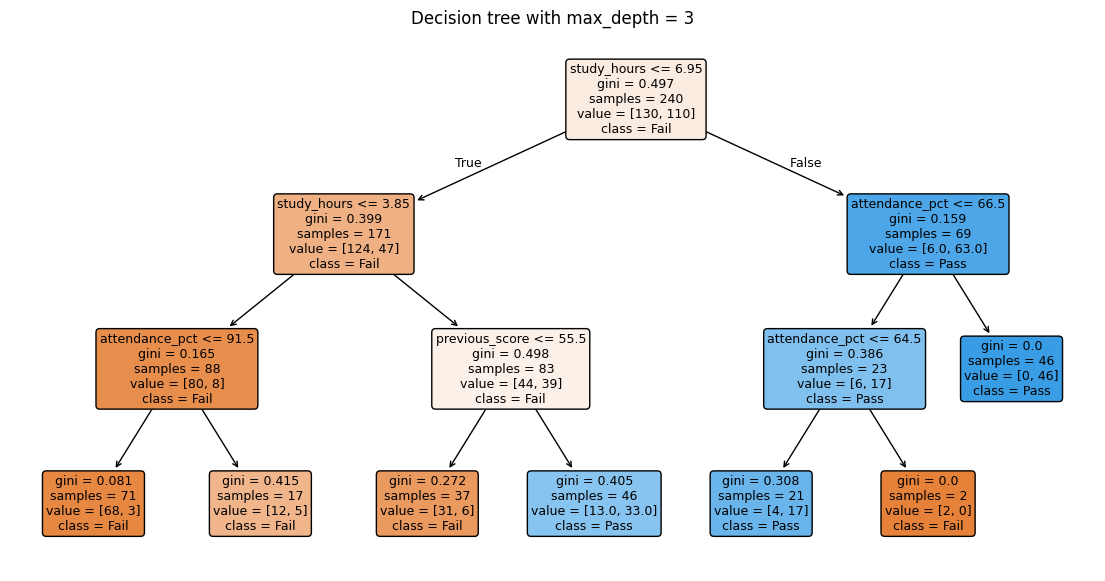

In [4]:
small_tree = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)

plt.figure(figsize=(14, 7))
plot_tree(small_tree, feature_names=features, class_names=["Fail", "Pass"], filled=True, rounded=True, fontsize=9)
plt.title("Decision tree with max_depth = 3")
plt.show()

Each box shows the question, how many students reached it (`samples`), the split of fail/pass (`value`) and the majority class. Darker colors mean a purer group. The very first question uses `study_hours`, the most informative feature.

## 4. Overfitting: What Happens When the Tree Grows Deeper?

We train trees of depth 1 to 10 and compare accuracy on the **training** data and on the **test** data.

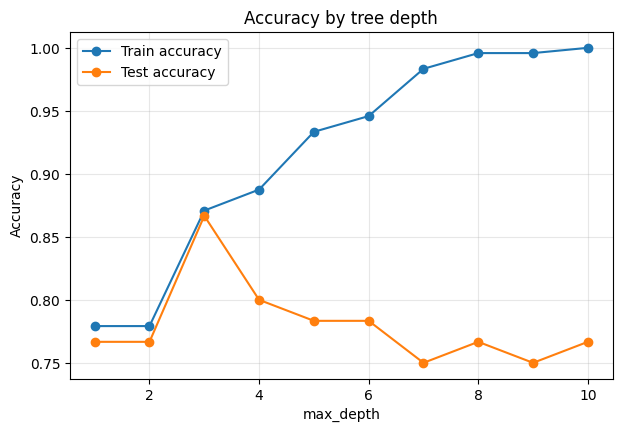

,depth,train,test
0,1,0.779,0.767
1,2,0.779,0.767
2,3,0.871,0.867
3,4,0.888,0.800
4,5,0.933,0.783
5,6,0.946,0.783
6,7,0.983,0.750
7,8,0.996,0.767
8,9,0.996,0.750
9,10,1.000,0.767


In [5]:
depths = list(range(1, 11))
train_acc, test_acc = [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_acc.append(t.score(X_train, y_train))
    test_acc.append(t.score(X_test, y_test))

plt.figure(figsize=(7, 4.5))
plt.plot(depths, train_acc, marker="o", label="Train accuracy")
plt.plot(depths, test_acc, marker="o", label="Test accuracy")
plt.title("Accuracy by tree depth")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

pd.DataFrame({"depth": depths, "train": np.round(train_acc, 3), "test": np.round(test_acc, 3)})

**How to read this:** training accuracy climbs towards 100% as the tree gets deeper, because it starts memorizing individual students. Test accuracy does **not** follow, and at large depths it ends up at roughly 75 to 77%. The widening gap between the two lines is **overfitting**.

Also notice that the test accuracy jumps around (a depth-3 tree scores higher than a depth-5 tree). The test set has only 60 students, so a single split is noisy. That is why we should not choose the depth by looking at the test set.

## 5. Choose the Depth with Cross-Validation

We use **5-fold cross-validation on the training data only** to pick the depth, and keep the test set for the final check.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = [cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42), X_train, y_train, cv=cv).mean()
             for d in depths]
best_depth = depths[int(np.argmax(cv_scores))]
print("Best depth by cross-validation:", best_depth, "| CV accuracy:", round(max(cv_scores), 3))

Best depth by cross-validation: 5 | CV accuracy: 0.788


## 6. Final Model and Evaluation on Test Data

In [7]:
model = DecisionTreeClassifier(max_depth=best_depth, random_state=42).fit(X_train, y_train)
pred = model.predict(X_test)

print(f"Train accuracy: {model.score(X_train, y_train):.3f}")
print(f"Test accuracy : {accuracy_score(y_test, pred):.3f}\n")
print(classification_report(y_test, pred, target_names=["Fail", "Pass"]))

Train accuracy: 0.933
Test accuracy : 0.783

              precision    recall  f1-score   support

        Fail       0.78      0.85      0.81        33
        Pass       0.79      0.70      0.75        27

    accuracy                           0.78        60
   macro avg       0.78      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60



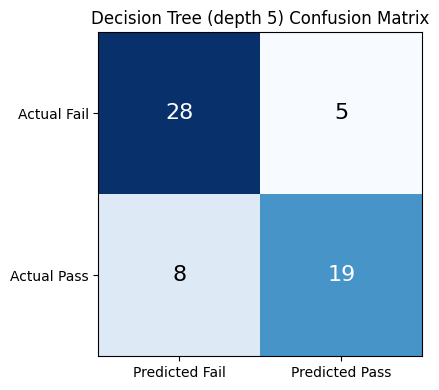

In [8]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1], ["Predicted Fail", "Predicted Pass"])
    ax.set_yticks([0, 1], ["Actual Fail", "Actual Pass"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=16,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_confusion(y_test, pred, f"Decision Tree (depth {best_depth}) Confusion Matrix")

## 7. Which Features Matter Most?

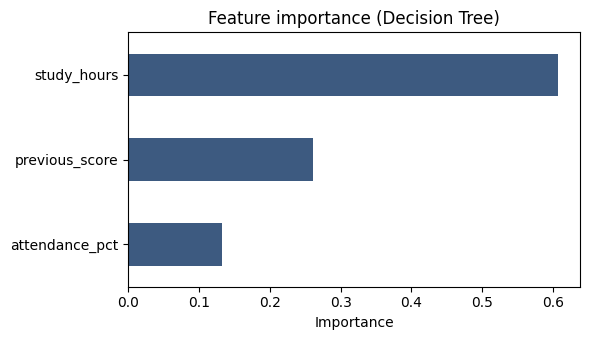

attendance_pct    0.132
previous_score    0.261
study_hours       0.607
dtype: float64

In [9]:
importance = pd.Series(model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(6, 3.5))
importance.plot(kind="barh", color="#3D5A80")
plt.title("Feature importance (Decision Tree)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importance.round(3)

## Conclusion

- A decision tree is very easy to **explain**: you can follow the questions from the top to a prediction.
- Left to grow deep, it **overfits**: training accuracy approaches 100% while test accuracy falls to roughly 75 to 77%.
- Cross-validation chose a depth of **5**, with a test accuracy of about **78%**. This is lower than logistic regression (88%) and KNN (87%).
- `study_hours` is the most important feature (about 61% of the importance), followed by `previous_score` and `attendance_pct`.
- A single tree is **unstable**: small changes in the data can change it a lot. The next notebook fixes this by combining many trees into a **Random Forest**.